In [1]:
from backbone import ConvNextDino
from visual_search import VisualSearchModel

import torch
import matplotlib.pyplot as plt
from torchvision.transforms import v2

def make_transform(resize_size: int = 256):
    to_tensor = v2.ToImage()
    resize = v2.Resize((resize_size, resize_size), antialias=True)
    to_float = v2.ToDtype(torch.float32, scale=True)
    normalize = v2.Normalize(
        mean=(0.430, 0.411, 0.296),
        std=(0.213, 0.156, 0.143),
    )
    return v2.Compose([to_tensor, resize, to_float, normalize])

from dataset_handler import COCODatasetHandler
coco = COCODatasetHandler("../CoCo", "train2017")
IMG_SIZE = 224

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/pydantic/_internal/_generat

loading annotations into memory...
Done (t=3.82s)
creating index...
index created!


In [2]:
examples = list()
for cat in coco.get_all_categories():
    examples = examples + coco.find_instances(cat, 10, max_area=3000, min_area=2000, grayscale=False)

In [3]:
backbone = ConvNextDino(len(coco.get_all_categories()))
backbone.to(device)
model = VisualSearchModel(backbone, device=str(device))

transform = make_transform(IMG_SIZE)

In [4]:
# Prepare batch data
batch_images = []
batch_bboxes = []

for instance in examples:
    # Get image
    img = instance['image']
    
   
    # Store original dimensions for bbox scaling
    orig_height, orig_width = img.size
    img_tensor = transform(img)
    
    batch_images.append(img_tensor)
    
    # Transform bounding box coordinates from original to resized image space
    bbox_orig = instance['bbox_dict']
    scale_x = IMG_SIZE / orig_width
    scale_y = IMG_SIZE / orig_height
    
    bbox_transformed = {
        'x1': bbox_orig['x1'] * scale_x,
        'y1': bbox_orig['y1'] * scale_y,
        'x2': bbox_orig['x2'] * scale_x,
        'y2': bbox_orig['y2'] * scale_y
    }
    batch_bboxes.append(bbox_transformed)

# Stack into a batch tensor
example_batch = torch.stack(batch_images).to(device)

In [5]:
# test = model.backbone.convnext_dino.stages(example_batch)
scene_responses = model._apply_backbone(example_batch)

_, _, feat_height, feat_width = scene_responses.shape
_, _, img_height, img_width = example_batch.shape

# Compute scaling from transformed image space to feature map space
scale_x = feat_width / img_width
scale_y = feat_height / img_height

# Extract response vectors for each instance at its target center
response_vectors = []

for batch_idx, bbox in enumerate(batch_bboxes):
    # Get bounding box coordinates (already in transformed image space)
    x1, y1 = bbox['x1'], bbox['y1']
    x2, y2 = bbox['x2'], bbox['y2']

    # Calculate target center in transformed image space
    center_x_img = (x1 + x2) / 2.0
    center_y_img = (y1 + y2) / 2.0

    # Convert to feature map space
    center_x_feat = center_x_img * scale_x
    center_y_feat = center_y_img * scale_y

    # Round and clamp to valid indices
    center_x_feat = int(round(center_x_feat))
    center_y_feat = int(round(center_y_feat))
    center_x_feat = max(0, min(center_x_feat, feat_width - 1))
    center_y_feat = max(0, min(center_y_feat, feat_height - 1))

    # Extract response vector at target center
    # batch_responses is (B, C, H, W), index as [batch, channels, y, x]
    response_vector = scene_responses[batch_idx, :, center_y_feat, center_x_feat]
    response_vectors.append(response_vector)

# Stack all response vectors: (num_instances, num_channels)
stacked_responses = torch.stack(response_vectors, dim=0)

In [6]:
print(stacked_responses.shape)

torch.Size([800, 1024])


In [7]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Convert to numpy for sklearn
responses_np = stacked_responses.detach().cpu().numpy()

# Perform PCA
pca = PCA(n_components=2)
responses_pca = pca.fit_transform(responses_np)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PCA shape: {responses_pca.shape}")

PCA explained variance ratio: [0.2615076  0.03080994]
Total variance explained: 0.2923
PCA shape: (800, 2)


In [8]:
# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5, init="random")
responses_tsne = tsne.fit_transform(responses_np)

print(f"t-SNE shape: {responses_tsne.shape}")

t-SNE shape: (800, 2)


In [9]:
# Extract category labels for coloring the plots
categories = coco.get_all_categories()
unique_categories = sorted(set(categories))
category_to_idx = {cat: idx for idx, cat in enumerate(unique_categories)}
category_indices = [category_to_idx[example["category_name"]] for example in examples]

print(f"Number of unique categories: {len(unique_categories)}")

Number of unique categories: 80


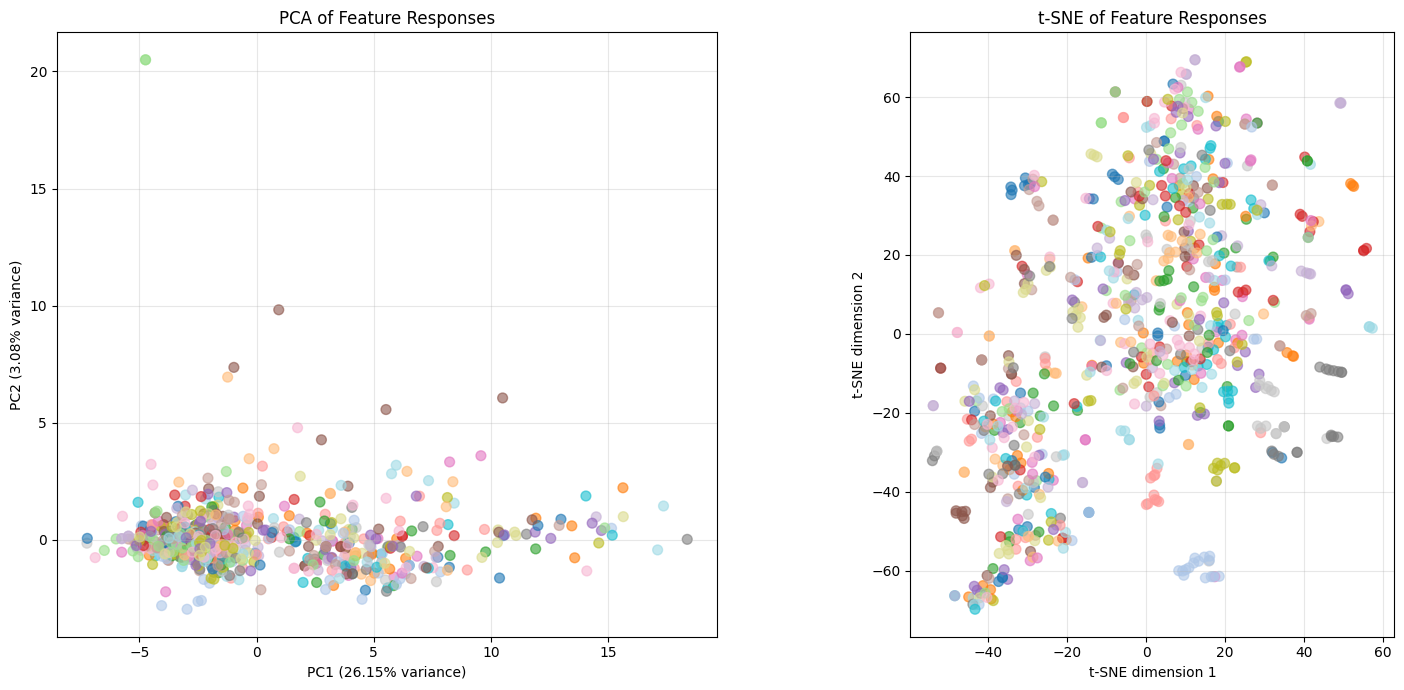

In [10]:
# Visualize PCA results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# PCA plot
scatter1 = ax1.scatter(responses_pca[:, 0], responses_pca[:, 1], 
                       c=category_indices, cmap='tab20', alpha=0.6, s=50)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax1.set_title('PCA of Feature Responses')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', 'box')

# t-SNE plot
scatter2 = ax2.scatter(responses_tsne[:, 0], responses_tsne[:, 1], 
                       c=category_indices, cmap='tab20', alpha=0.6, s=50)
ax2.set_xlabel('t-SNE dimension 1')
ax2.set_ylabel('t-SNE dimension 2')
ax2.set_title('t-SNE of Feature Responses')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()